Getting the data from Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fmendes/fmendesdat263xdemos")

print("Path to dataset files:", path)

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 296k/296k [00:00<00:00, 577kB/s]

Extracting files...
Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\fmendes\fmendesdat263xdemos\versions\1


In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fmendes/fmendesdat263xdemos")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\User\.cache\kagglehub\datasets\fmendes\fmendesdat263xdemos\versions\1


Importing all dependencies

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import sklearn.metrics as metrics

In [13]:
#Loading the data to a pandas dataframe

calory_data = pd.read_csv(r'C:\Users\User\ML_crush_course\ML_challenges\calories.csv')
exercise_data = pd.read_csv(r"C:\Users\User\ML_crush_course\ML_challenges\exercise.csv")

In [4]:
#Checking the first 5 rows of the data

calory_data.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [7]:
#getting the info about the data
calory_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


In [8]:
#Checking the number of columns and rows in the data
calory_data.shape

(15000, 2)

In [9]:
#Checking the statistical summary of the data
calory_data.isnull().sum()

User_ID     0
Calories    0
dtype: int64

In [11]:
#Getting the statistical summary of the data
calory_data.describe()

,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


In [14]:
#Working with the exercise data
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [15]:
#getting the number of columns and rows in the data
exercise_data.shape

(15000, 8)

In [16]:
#checking for null values in the data
exercise_data.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64

Combining the two Dataframes

In [17]:
calories_data = pd.concat([exercise_data, calory_data], axis=1)

In [18]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,14733363,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,14861698,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,11179863,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,16180408,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,17771927,35.0


In [19]:
#checking the numbe of columns and rows in the data
calories_data.shape

(15000, 10)

Data analysing and Visualizing

Text(0.5, 1.0, 'Distribution of Calories Burned')

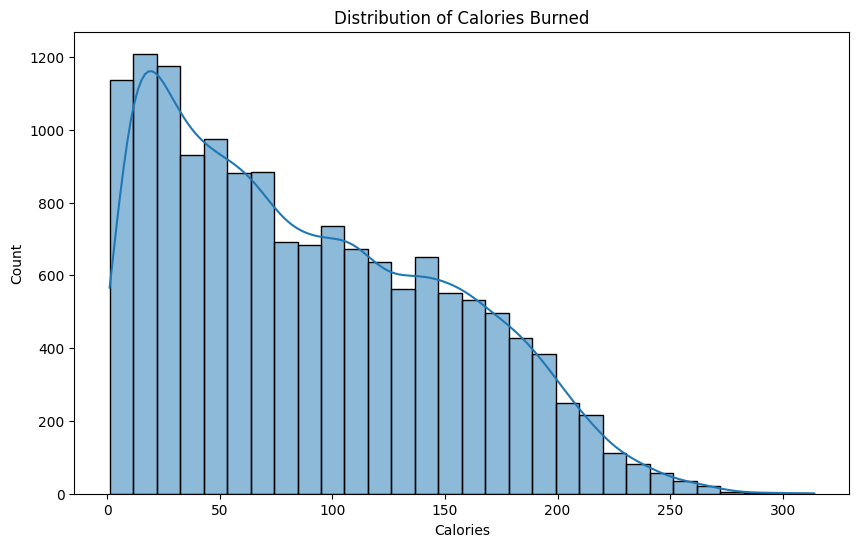

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(calories_data['Calories'], bins=30, kde=True)
plt.title('Distribution of Calories Burned')

Text(0.5, 1.0, 'Distribution of Calories Burned across Gender')

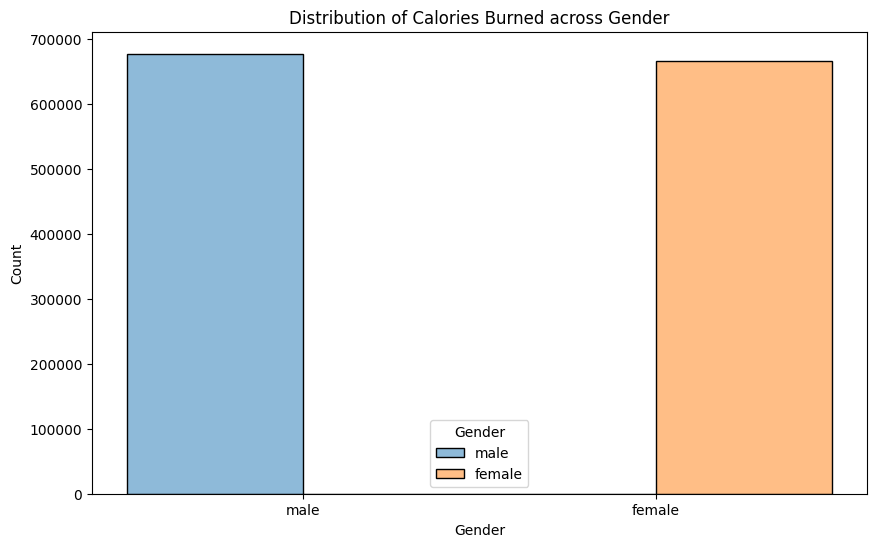

In [22]:
#the distribution of calories around the gender
plt.figure(figsize=(10, 6))
sns.histplot(data=calories_data, x='Gender', hue='Gender', weights='Calories', kde=True, multiple='dodge')
plt.title('Distribution of Calories Burned across Gender')

In [29]:
sns.set()

<Axes: ylabel='count'>

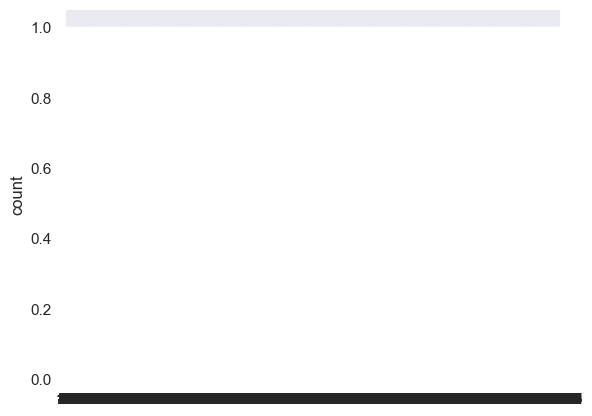

In [30]:
#plotting the gender distribution

sns.countplot( calories_data['Gender'])

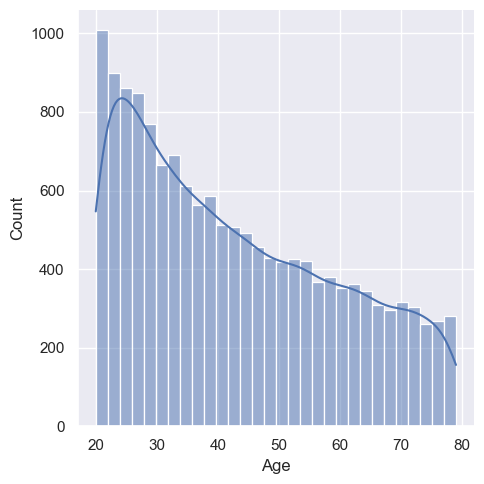

In [32]:
#Distribution of age columns

sns.displot(calories_data['Age'], bins=30, kde=True)

In [23]:
#getting the statistical summary of the data
calories_data.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,1.497736e+07,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,2.872851e+06,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000116e+07,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,1.247419e+07,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,1.499728e+07,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,1.744928e+07,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,1.999965e+07,314.000000


Encoding the data

In [24]:
#encoding gender column

calories_data['Gender'] = calories_data['Gender'].map({'male':0, 'female':1})

In [25]:
calories_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,User_ID,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,14733363,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,14861698,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,11179863,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,16180408,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,17771927,35.0


Finding the correlation between data

In [37]:
correlation_matrix = calories_data.corr()

<Axes: >

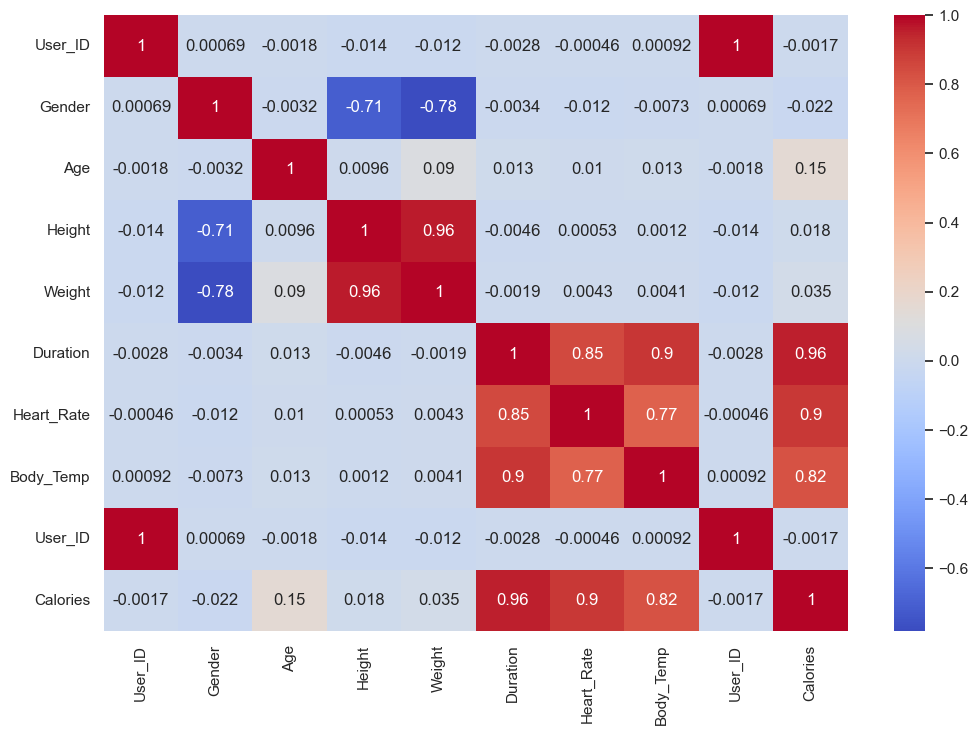

In [39]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')

Splitting the data into trainin and testing data

In [27]:
X = calories_data.drop(columns=['Calories', 'User_ID'], axis=1)

Y = calories_data['Calories']

In [28]:
print(X)
print(Y)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]
0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999   

In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, 
    Y,
    test_size=0.2,
    random_state=2
)

In [33]:
print(X.shape, X_train.shape, X_train.shape, Y_train.shape, Y_test.shape)

(15000, 7) (12000, 7) (12000, 7) (12000,) (3000,)


Training the model

In [34]:
xgboost = xgb.XGBRegressor()

In [36]:
xgboost.fit(X_train, Y_train )

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

Evaluating the model

In [40]:
#training prediction
training_prediction = xgboost.predict(X_train)

#R squared error
error_r2 = metrics.r2_score(Y_train, training_prediction)

print('R squared error : ', error_r2)

R squared error :  0.9995691477017405


In [41]:
#testing prediction

testing_pred = xgboost.predict(X_test)

#R squared error
error_r2 = metrics.r2_score(Y_test, testing_pred)

print('R squared error : ', error_r2)

R squared error :  0.998800624504713


Implementing another model

In [42]:
lightgbm = lgb.LGBMRegressor()

In [43]:
lightgbm.fit(X_train, Y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 364
[LightGBM] [Info] Number of data points in the train set: 12000, number of used features: 7
[LightGBM] [Info] Start training from score 89.586750


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Evaluating the model

In [44]:
#training prediction
training_prediction = lightgbm.predict(X_train)

#R squared error
error_r2 = metrics.r2_score(Y_train, training_prediction)   

print('R squared error : ', error_r2)

R squared error :  0.9993668597993944


In [45]:
#testing prediction
testing_pred = lightgbm.predict(X_test)
#R squared error
error_r2 = metrics.r2_score(Y_test, testing_pred)
print('R squared error : ', error_r2)


R squared error :  0.9991003455915279


Making the predcitive system

In [47]:
#building the predictive system
input_data = (0,68,190.0,	94.0,	29.0,	105.0,	40.8 )

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

prediction = xgboost.predict(input_data_reshaped)

print('The calories burned is : ', prediction[0])

The calories burned is :  236.13371


Visualizing the data

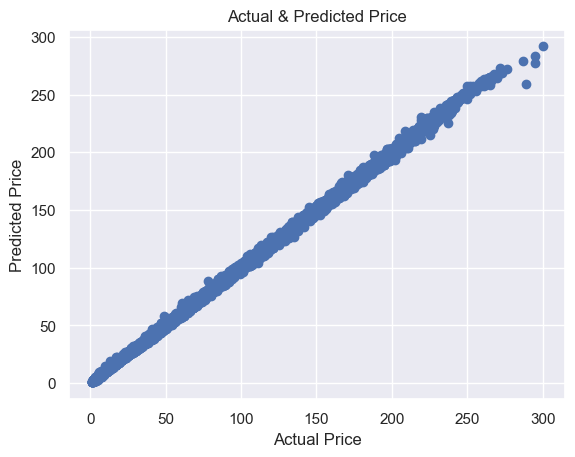

In [48]:
plt.scatter(Y_train, training_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual & Predicted Price")
plt.show()